## LABOR: SDR-Kalibration mit bekannter Signalquelle

← [RTL-SDR-Samples](rtl_sdr_samples.ipynb)

**Ziel:** Mit einer **bekannten Referenzquelle** (unmodulierter Sinusträger; Frequenz und Leistung werden vorgegeben) den SDR-Empfang kalibrieren. Durch Einlesen und **Mittelung von M Betragsspektren** wird der **Peak-Wert des Trägers** ermittelt. Daraus wird ein **Kalibrierfaktor** (vorgegebener Wert / gemessener Wert) berechnet und in **`calibration.json`** gespeichert, damit er in späteren Auswertungen wiederverwendet werden kann. Die Kalibrierung wird für die **Gain-Einstellungen 0, 10, 20, 30, 40 und 47 dB** durchgeführt und alle Faktoren werden in derselben Datei abgelegt.



### Windows: Treiber-Pfad setzen (vor dem Import)

Falls du unter Windows arbeitest: Zelle ausführen, damit **librtlsdr.dll** aus dem Ordner **rtl-sdr-driver** gefunden wird.

In [5]:
import os
from pathlib import Path

_driver_dir = None
for p in [Path.cwd()] + list(Path.cwd().parents):
    candidate = p / "rtl-sdr-driver"
    if candidate.exists() and (candidate / "librtlsdr.dll").exists():
        _driver_dir = candidate
        break
if _driver_dir is not None:
    _path = str(_driver_dir)
    os.environ["PATH"] = _path + os.pathsep + os.environ.get("PATH", "")
    if hasattr(os, "add_dll_directory"):
        os.add_dll_directory(_path)
    print("RTL-SDR Treiber gefunden:", _driver_dir)
else:
    print("Hinweis: rtl-sdr-driver (librtlsdr.dll) nicht gefunden.")

RTL-SDR Treiber gefunden: C:\Users\kissb\_Git\KT-course\rtl-sdr-driver


### Aufgabenstellung

1. **Referenzquelle:** Es steht ein **unmodulierter Sinusträger** mit bekannter **Frequenz** $f_{\mathrm{ref}}$ und bekannter **Leistung** $P_{\mathrm{ref}}$ (z. B. in dBm) zur Verfügung. Diese Werte werden vom Betreuer vorgegeben.

2. **Messung:** Für eine feste Gain-Einstellung des SDR werden **M** aufeinanderfolgende Blöcke von **N** Samples eingelesen. Pro Block wird das **Betragsspektrum** (FFT, Betrag) berechnet. Anschließend werden die **M Betragsspektren gemittelt** und aus dem gemittelten Spektrum der **Peak-Wert** an der Referenzfrequenz (bzw. im zugehörigen FFT-Bin) ermittelt → **gemessener Peak** $A_{\mathrm{gem}}$.

3. **Kalibrierfaktor:**
   $$
   K = \frac{\text{vorgegebener Referenzwert}}{\text{gemessener Peak}}.
   $$
   Später: kalibrierter Wert = gemessener Wert × $K$.

4. **Speicherung:** Der Kalibrierfaktor (sowie die zugehörigen Einstellungen und Referenzwerte) wird in **`calibration.json`** im gleichen Ordner wie dieses Notebook gespeichert, damit er in anderen Auswertungen (z. B. SDR-Radiolink) geladen und verwendet werden kann.

5. **Gain-Sweep:** Der gesamte Vorgang (Einlesen, Mittelung, Peak, Kalibrierfaktor) wird für die **Gain-Einstellungen 0, 10, 20, 30, 40 und 47 dB** ausgeführt; alle Ergebnisse werden in **`calibration.json`** abgelegt (pro Gain ein Eintrag).

### Parameter (von Betreuer vorgegeben / anpassbar)

- **Referenzfrequenz** $f_{\mathrm{ref}}$ (Hz) und **Referenzleistung** $P_{\mathrm{ref}}$ (dBm) der Kalibrierquelle.
- **N:** Anzahl Samples pro Block (FFT-Länge).
- **M:** Anzahl der gemittelten Betragsspektren pro Gain-Stufe.
- **Gain-Stufen:** 0, 10, 20, 30, 40, 47 dB.
- **SAVE_PLOTS:** Wenn `True`, wird pro Gain ein Spektralplot als PNG gespeichert (`calibration_gain_0.png`, …).

Gain  0 dB: Peak @ 0.000000 MHz, A = 6.77 A_dB = 16.61 → K = 1.48e-05 (Cal.Offset -96.61 dB, Frequ.Bin 2048)
Gain 10 dB: Peak @ 0.000000 MHz, A = 6.39 A_dB = 16.11 → K = 1.56e-05 (Cal.Offset -96.11 dB, Frequ.Bin 2048)
Warnung: Peak-Bin bei Gain 20 dB verschoben (Bin 2060, ΔBin=12).
Gain 20 dB: Peak @ 0.006000 MHz, A = 14.43 A_dB = 23.19 → K = 6.93e-06 (Cal.Offset -103.19 dB, Frequ.Bin 2060)
Warnung: Peak-Bin bei Gain 30 dB verschoben (Bin 2060, ΔBin=12).
Gain 30 dB: Peak @ 0.006000 MHz, A = 34.86 A_dB = 30.85 → K = 2.87e-06 (Cal.Offset -110.85 dB, Frequ.Bin 2060)
Warnung: Peak-Bin bei Gain 40 dB verschoben (Bin 2060, ΔBin=12).
Gain 40 dB: Peak @ 0.006000 MHz, A = 179.76 A_dB = 45.09 → K = 5.56e-07 (Cal.Offset -125.09 dB, Frequ.Bin 2060)
Warnung: Peak-Bin bei Gain 50 dB verschoben (Bin 2060, ΔBin=12).
Gain 50 dB: Peak @ 0.006000 MHz, A = 328.73 A_dB = 50.34 → K = 3.04e-07 (Cal.Offset -130.34 dB, Frequ.Bin 2060)

Kalibrierung gespeichert: C:\Users\kissb\_Git\KT-course\lab_suite\labs\03_0

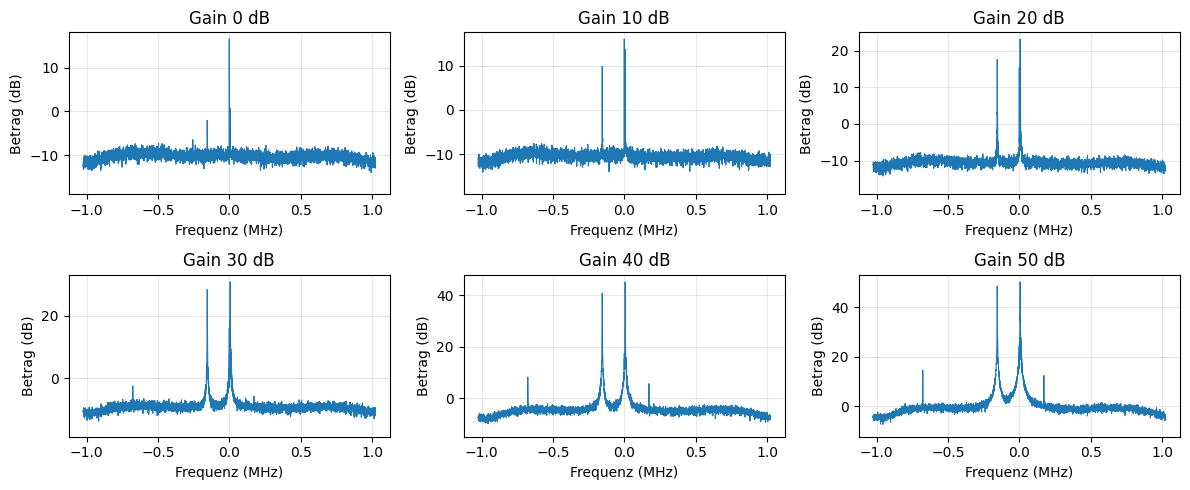

  Plot gespeichert: C:\Users\kissb\_Git\KT-course\lab_suite\labs\03_02_LABOR-2\submissions\calibration_gain_0.png
  Plot gespeichert: C:\Users\kissb\_Git\KT-course\lab_suite\labs\03_02_LABOR-2\submissions\calibration_gain_10.png
  Plot gespeichert: C:\Users\kissb\_Git\KT-course\lab_suite\labs\03_02_LABOR-2\submissions\calibration_gain_20.png
  Plot gespeichert: C:\Users\kissb\_Git\KT-course\lab_suite\labs\03_02_LABOR-2\submissions\calibration_gain_30.png
  Plot gespeichert: C:\Users\kissb\_Git\KT-course\lab_suite\labs\03_02_LABOR-2\submissions\calibration_gain_40.png
  Plot gespeichert: C:\Users\kissb\_Git\KT-course\lab_suite\labs\03_02_LABOR-2\submissions\calibration_gain_50.png


{'reference_freq_hz': 434000000.0,
 'reference_power_dbm': -80.0,
 'sample_rate_hz': 2048000.0,
 'N': 4096,
 'M': 32,
 'gains': [{'gain_dB': 0,
   'measured_peak_magnitude': 6.769934221082737,
   'measured_peak_dB': np.float64(16.6117),
   'calibration_offset_dB': np.float64(-96.6117),
   'calibration_factor_linear': np.float64(1.5e-05),
   'peak_bin': 2048,
   'peak_freq_hz': 0.0},
  {'gain_dB': 10,
   'measured_peak_magnitude': 6.393521631925937,
   'measured_peak_dB': np.float64(16.1148),
   'calibration_offset_dB': np.float64(-96.1148),
   'calibration_factor_linear': np.float64(1.6e-05),
   'peak_bin': 2048,
   'peak_freq_hz': 0.0},
  {'gain_dB': 20,
   'measured_peak_magnitude': 14.434315135037753,
   'measured_peak_dB': np.float64(23.1879),
   'calibration_offset_dB': np.float64(-103.1879),
   'calibration_factor_linear': np.float64(7e-06),
   'peak_bin': 2060,
   'peak_freq_hz': 6000.0},
  {'gain_dB': 30,
   'measured_peak_magnitude': 34.855078731492384,
   'measured_peak_dB': 

In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ========== Parameter (vom Betreuer vorgegeben / anpassen) ==========
REFERENCE_FREQ_HZ = 434e6          # Frequenz des unmodulierten Trägers (Hz)
REFERENCE_POWER_DBM = -80.0         # Vorgegebene Leistung der Referenzquelle (dBm)
NUM_SAMPLES = 4096                  # N: Samples pro Block (FFT-Länge)
NUM_AVERAGES = 32                   # M: Anzahl der gemittelten Betragsspektren
SAMPLE_RATE_HZ = 2.048e6
GAINS_DB = [0, 10, 20, 30, 40, 50]

# Plots als Bild speichern? (pro Gain eine PNG-Datei)
SAVE_PLOTS = True
PLOT_DIR = Path.cwd()  # Ordner für calibration_gain_0.png, ...

# calibration.json: wird im aktuellen Arbeitsverzeichnis erzeugt.
CALIBRATION_PATH = Path.cwd() / "calibration.json"

def run_calibration(do_plot=True, save_plots=SAVE_PLOTS):
    try:
        from rtlsdr import RtlSdr
    except ImportError:
        print("rtlsdr nicht installiert. Bitte installieren: pip install pyrtlsdr")
        return None

    N = NUM_SAMPLES
    M = NUM_AVERAGES
    fs = SAMPLE_RATE_HZ
    center_freq_hz = REFERENCE_FREQ_HZ
    results = {
        "reference_freq_hz": REFERENCE_FREQ_HZ,
        "reference_power_dbm": REFERENCE_POWER_DBM,
        "sample_rate_hz": fs,
        "N": N,
        "M": M,
        "gains": [],
    }
    plot_data = []  # Liste von (gain_db, freq_mhz, magnitude_dB)

    sdr = RtlSdr()
    try:
        sdr.sample_rate = fs
        sdr.center_freq = center_freq_hz
        for gain_db in GAINS_DB:
            sdr.gain = gain_db
            magnitude_sum = np.zeros(N, dtype=np.float64)
            for _ in range(M):
                samples = sdr.read_samples(N)
                X = np.fft.fft(samples)
                magnitude_sum += np.abs(X)
            magnitude_avg = magnitude_sum / M
            freq = np.fft.fftshift(np.fft.fftfreq(N, 1 / fs))
            magnitude_shifted = np.fft.fftshift(magnitude_avg)
            magnitude_dB = 20 * np.log10(magnitude_shifted + 1e-20)
            freq_mhz = freq / 1e6
            # Peak-Bin im gemittelten, geshifteten Spektrum bestimmen
            peak_bin = int(np.argmax(magnitude_shifted))
            peak_freq_hz = float(freq[peak_bin])
            peak_freq_mhz = peak_freq_hz / 1e6

            measured_peak_magnitude = float(magnitude_shifted[peak_bin])
            measured_peak_dB = -200.0 if measured_peak_magnitude < 1e-20 else 20 * np.log10(measured_peak_magnitude)
            calibration_offset_dB = REFERENCE_POWER_DBM - measured_peak_dB
            calibration_factor_linear = 10 ** (calibration_offset_dB / 20.0)

            # Konsistenzcheck über alle Gains: erster Peak-Bin als Referenz
            if not results["gains"]:
                results["reference_peak_bin"] = peak_bin
                results["reference_peak_freq_hz"] = peak_freq_hz
            else:
                ref_bin = results.get("reference_peak_bin")
                if ref_bin is not None:
                    delta_bin = peak_bin - ref_bin
                    if abs(delta_bin) > 1:
                        print(f"Warnung: Peak-Bin bei Gain {gain_db} dB verschoben (Bin {peak_bin}, ΔBin={delta_bin}).")

            results["gains"].append({
                "gain_dB": gain_db,
                "measured_peak_magnitude": measured_peak_magnitude,
                "measured_peak_dB": round(measured_peak_dB, 4),
                "calibration_offset_dB": round(calibration_offset_dB, 4),
                "calibration_factor_linear": round(calibration_factor_linear, 6),
                "peak_bin": peak_bin,
                "peak_freq_hz": round(peak_freq_hz, 1),
            })
            plot_data.append((gain_db, freq_mhz.copy(), magnitude_dB.copy()))
            print(
                f"Gain {gain_db:2d} dB: Peak @ {peak_freq_mhz:.6f} MHz, "
                f"A = {measured_peak_magnitude:.2f} A_dB = {measured_peak_dB:.2f} → K = {calibration_factor_linear:.2e} "
                f"(Cal.Offset {calibration_offset_dB:+.2f} dB, Frequ.Bin {peak_bin})"
            )
    finally:
        sdr.close()

    with open(CALIBRATION_PATH, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2, ensure_ascii=False)
    print(f"\nKalibrierung gespeichert: {CALIBRATION_PATH}")

    # Gemitteltes Betragsspektrum (Log-Skala) pro Gain plotten
    if do_plot and plot_data:
        n_gains = len(plot_data)
        n_cols = 3
        n_rows = (n_gains + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 2.5 * n_rows), squeeze=False)
        axes_flat = axes.flatten()
        for idx, (gain_db, freq_mhz, mag_dB) in enumerate(plot_data):
            ax = axes_flat[idx]
            ax.plot(freq_mhz, mag_dB, color="C0", linewidth=0.8)
            ax.set_xlabel("Frequenz (MHz)")
            ax.set_ylabel("Betrag (dB)")
            ax.set_title(f"Gain {gain_db} dB")
            ax.grid(True, alpha=0.3)
            ax.set_ylim(bottom=np.nanmin(mag_dB) - 5 if np.any(np.isfinite(mag_dB)) else -100)
        for j in range(len(plot_data), len(axes_flat)):
            axes_flat[j].set_visible(False)
        plt.tight_layout()
        plt.show()

        # Optional: pro Gain ein Bild speichern
        if save_plots:
            PLOT_DIR.mkdir(parents=True, exist_ok=True)
            for gain_db, freq_mhz, mag_dB in plot_data:
                fig1, ax1 = plt.subplots(1, 1, figsize=(8, 3))
                ax1.plot(freq_mhz, mag_dB, color="C0", linewidth=0.8)
                ax1.set_xlabel("Frequenz (MHz)")
                ax1.set_ylabel("Betrag (dB)")
                ax1.set_title(f"Kalibrierung Gain {gain_db} dB")
                ax1.grid(True, alpha=0.3)
                plt.tight_layout()
                out_path = PLOT_DIR / f"calibration_gain_{gain_db}.png"
                fig1.savefig(out_path, dpi=150, bbox_inches="tight")
                plt.close(fig1)
                print(f"  Plot gespeichert: {out_path}")

    return results

run_calibration(do_plot=True, save_plots=SAVE_PLOTS)

 

### Optional: Schrittweise messen (ein Gain nach dem anderen)

Statt alle Gains in einem Durchlauf zu messen, kannst du **pro Gain** messen, das **gemittelte Betragsspektrum in Log-Skala** ansehen und mit **„Nächstes Gain“** weiterschalten. Nach dem letzten Gain wird `calibration.json` geschrieben. Setze `SAVE_PLOTS_STEP = True`, um pro Gain eine PNG-Datei zu speichern.

In [7]:
# Schrittweise Kalibrierung: Ein Gain nach dem anderen, Plot ansehen, dann "Nächstes Gain"
SAVE_PLOTS_STEP = True  # Pro Gain ein Bild speichern (calibration_gain_0.png, ...)

from ipywidgets import Button, VBox, Output, Label
from IPython.display import display, clear_output

try:
    from rtlsdr import RtlSdr
except ImportError:
    print("rtlsdr nicht installiert. Bitte zuerst die Zelle mit run_calibration() ausführen oder pip install pyrtlsdr")
else:
    step_out = Output()
    step_label = Label(value="Klicke 'Nächstes Gain', um mit Gain 0 dB zu starten.")
    step_results = []
    step_plot_dir = Path.cwd()

    def on_next_gain(_):
        global step_results
        with step_out:
            clear_output(wait=True)
            idx = len(step_results)
            if idx >= len(GAINS_DB):
                print("Alle Gains gemessen. Bereits in calibration.json gespeichert.")
                return
            gain_db = GAINS_DB[idx]
            N, M, fs = NUM_SAMPLES, NUM_AVERAGES, SAMPLE_RATE_HZ
            sdr = RtlSdr()
            try:
                sdr.sample_rate = fs
                sdr.center_freq = REFERENCE_FREQ_HZ
                sdr.gain = gain_db
                magnitude_sum = np.zeros(N, dtype=np.float64)
                for _ in range(M):
                    samples = sdr.read_samples(N)
                    magnitude_sum += np.abs(np.fft.fft(samples))
                magnitude_avg = magnitude_sum / M
                freq = np.fft.fftshift(np.fft.fftfreq(N, 1 / fs))
                magnitude_shifted = np.fft.fftshift(magnitude_avg)
                magnitude_dB = 20 * np.log10(magnitude_shifted + 1e-20)
                freq_mhz = freq / 1e6
            finally:
                sdr.close()
            peak_bin = N // 2
            measured_peak_magnitude = float(magnitude_shifted[peak_bin])
            measured_peak_dB = -200.0 if measured_peak_magnitude < 1e-20 else 20 * np.log10(measured_peak_magnitude)
            calibration_offset_dB = REFERENCE_POWER_DBM - measured_peak_dB
            calibration_factor_linear = 10 ** (calibration_offset_dB / 20.0)
            step_results.append({
                "gain_dB": gain_db,
                "measured_peak_magnitude": measured_peak_magnitude,
                "measured_peak_dB": round(measured_peak_dB, 4),
                "calibration_offset_dB": round(calibration_offset_dB, 4),
                "calibration_factor_linear": round(calibration_factor_linear, 6),
            })
            print(f"Gain {gain_db} dB: Peak = {measured_peak_magnitude:.2f} → K = {calibration_factor_linear:.4f} (Offset {calibration_offset_dB:+.2f} dB)")
            fig, ax = plt.subplots(1, 1, figsize=(8, 3))
            ax.plot(freq_mhz, magnitude_dB, color="C0", linewidth=0.8)
            ax.set_xlabel("Frequenz (MHz)")
            ax.set_ylabel("Betrag (dB)")
            ax.set_title(f"Gemitteltes Betragsspektrum — Gain {gain_db} dB")
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            display(fig)
            plt.close(fig)
            if SAVE_PLOTS_STEP:
                step_plot_dir.mkdir(parents=True, exist_ok=True)
                fig2, ax2 = plt.subplots(1, 1, figsize=(8, 3))
                ax2.plot(freq_mhz, magnitude_dB, color="C0", linewidth=0.8)
                ax2.set_xlabel("Frequenz (MHz)")
                ax2.set_ylabel("Betrag (dB)")
                ax2.set_title(f"Kalibrierung Gain {gain_db} dB")
                ax2.grid(True, alpha=0.3)
                plt.tight_layout()
                fig2.savefig(step_plot_dir / f"calibration_gain_{gain_db}.png", dpi=150, bbox_inches="tight")
                plt.close(fig2)
                print(f"Plot gespeichert: {step_plot_dir / f'calibration_gain_{gain_db}.png'}")
            if len(step_results) >= len(GAINS_DB):
                results = {
                    "reference_freq_hz": REFERENCE_FREQ_HZ,
                    "reference_power_dbm": REFERENCE_POWER_DBM,
                    "sample_rate_hz": fs,
                    "N": N,
                    "M": M,
                    "gains": step_results,
                }
                with open(CALIBRATION_PATH, "w", encoding="utf-8") as f:
                    json.dump(results, f, indent=2, ensure_ascii=False)
                print(f"\nAlle Gains gemessen. Kalibrierung gespeichert: {CALIBRATION_PATH}")
                step_label.value = "Fertig. calibration.json wurde geschrieben."
            else:
                next_g = GAINS_DB[len(step_results)]
                step_label.value = f"Gain {gain_db} dB erledigt. Nächstes: Gain {next_g} dB — klicke erneut 'Nächstes Gain'."

    btn_next = Button(description="Nächstes Gain", button_style="primary")
    btn_next.on_click(on_next_gain)
    display(VBox([step_label, btn_next, step_out]))

### Kalibrierung laden und wiederverwenden

In anderen Notebooks (z. B. SDR-Radiolink) kann `calibration.json` geladen werden, um gemessene Peak-Werte mit dem passenden Kalibrierfaktor zu korrigieren:  
`kalibrierter_Wert = gemessener_Peak * calibration_factor_linear` bzw. in dB:  
`P_kalibriert_dB = P_gemessen_dB + calibration_offset_dB`.

In [8]:
# Beispiel: calibration.json laden und für einen bestimmten Gain den Faktor verwenden
def load_calibration(path=None):
    path = path or Path("calibration.json")
    if not Path(path).exists():
        print("calibration.json nicht gefunden. Zuerst Kalibrierung ausführen (Zelle oben).")
        return None
    with open(path, encoding="utf-8") as f:
        return json.load(f)

cal = load_calibration()
if cal:
    print("Referenz:", cal["reference_freq_hz"] / 1e6, "MHz,", cal["reference_power_dbm"], "dBm")
    for g in cal["gains"]:
        print(f"  Gain {g['gain_dB']} dB → Faktor {g['calibration_factor_linear']:.4e}, Offset {g['calibration_offset_dB']:+.2f} dB")

Referenz: 434.0 MHz, -80.0 dBm
  Gain 0 dB → Faktor 1.5000e-05, Offset -96.61 dB
  Gain 10 dB → Faktor 1.6000e-05, Offset -96.11 dB
  Gain 20 dB → Faktor 7.0000e-06, Offset -103.19 dB
  Gain 30 dB → Faktor 3.0000e-06, Offset -110.85 dB
  Gain 40 dB → Faktor 1.0000e-06, Offset -125.09 dB
  Gain 50 dB → Faktor 0.0000e+00, Offset -130.34 dB
